In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from utility.utils import data_distribution_frame, columns_with_null

In [2]:
data = pd.read_csv('../data/application_train.csv')

In [3]:
data.shape

(307511, 122)

In [4]:
target = data['TARGET']
data.drop(columns=['TARGET'], inplace=True)

In [5]:
print(f'data = {data.shape}')
print(f'target = {target.shape}')

data = (307511, 121)
target = (307511,)


# Inspection of Target

## Distribution of the Target classes

In [6]:
class_distribution = data_distribution_frame(target)
class_distribution

,value counts,percent of total
0,282686,92%
1,24825,8%


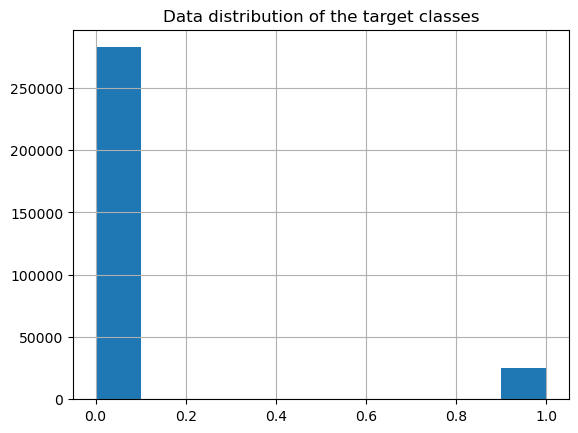

In [7]:
target.hist()
plt.title('Data distribution of the target classes')
plt.savefig('../reports/eda/target_classes_dist.png')

> This is a case of imbalanced classification.
>
> In creating a train-test split and also in using cross-validation for model selection, care must be taken to ensure that the class distribution is maintained in both train and test split.
>
> It will be necessary to use stratified sampling technique.

# Inspection of the feature columns

## Null values

In [8]:
null_columns = columns_with_null(data)

In [9]:
null_columns.head(5)

,column name,column dtype,percent of total,number of nulls
0,AMT_ANNUITY,float64,0,12
1,AMT_GOODS_PRICE,float64,0,278
2,OWN_CAR_AGE,float64,66,202929
3,CNT_FAM_MEMBERS,float64,0,2
4,EXT_SOURCE_1,float64,56,173378


In [10]:
categorical_columns_with_nulls = columns_with_null(data, 'non-numeric')
categorical_columns_with_nulls

,column name,column dtype,percent of total,number of nulls
0,NAME_TYPE_SUITE,object,0,1292
1,OCCUPATION_TYPE,object,31,96391
2,FONDKAPREMONT_MODE,object,68,210295
3,HOUSETYPE_MODE,object,50,154297
4,WALLSMATERIAL_MODE,object,51,156341
5,EMERGENCYSTATE_MODE,object,47,145755


> To fill the missing values a simple imputer can be used.
> for categorical columns, strategy='most_frequent'
> 
> for numeric columns, strategy='mean'
> 
> alteratively, IterativeImputer can be used with randomforestregressor passed as the estimator. However, this depends on the interrelationship between the feature columns.

## Encoding of Categorical columns

In [11]:
numeric_features = data.select_dtypes(exclude='object')
categorical_columns = data.select_dtypes(include='object')

In [12]:
count = 0
total = 0
for col in categorical_columns.columns: 
    print(f'{count+1:3} {col:27} - {categorical_columns[col].nunique()}')
    count += 1
    total += categorical_columns[col].nunique()
print('-------------------------------------')
print(f'Total = {total}')

  1 NAME_CONTRACT_TYPE          - 2
  2 CODE_GENDER                 - 3
  3 FLAG_OWN_CAR                - 2
  4 FLAG_OWN_REALTY             - 2
  5 NAME_TYPE_SUITE             - 7
  6 NAME_INCOME_TYPE            - 8
  7 NAME_EDUCATION_TYPE         - 5
  8 NAME_FAMILY_STATUS          - 6
  9 NAME_HOUSING_TYPE           - 6
 10 OCCUPATION_TYPE             - 18
 11 WEEKDAY_APPR_PROCESS_START  - 7
 12 ORGANIZATION_TYPE           - 58
 13 FONDKAPREMONT_MODE          - 4
 14 HOUSETYPE_MODE              - 3
 15 WALLSMATERIAL_MODE          - 7
 16 EMERGENCYSTATE_MODE         - 2
-------------------------------------
Total = 140


> Given a total of 140 unique categories, they can still be one-hot-encoded.

In [13]:
correlation_frame = pd.DataFrame(numeric_features.corr())
series = []
for col in correlation_frame: 
    mask = (correlation_frame[col] > 0.5) & (correlation_frame[col] < 1.0)
    series.append(pd.Series(correlation_frame[col][mask])) 

extracted_corr_frame = pd.concat(series, axis=1.0)
extracted_corr_frame.dropna(how='all', axis=1, inplace=True)

In [14]:
extracted_corr_frame.head()

,CNT_CHILDREN,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_EMP_PHONE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_6
CNT_FAM_MEMBERS,0.879161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMT_ANNUITY,NaN,0.770138,NaN,0.775109,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMT_GOODS_PRICE,NaN,0.986968,0.775109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMT_CREDIT,NaN,NaN,0.770138,0.986968,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_EMP_PHONE,NaN,NaN,NaN,NaN,0.619888,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> It appears some of the features are highly correlated.
>
> this makes it well suited for using InterativeImputer in handling the missing values.
>
> But it also introduces redundancy into the feature space and hence the need for dimensionality reduction.

> for dimensionality reduction, PCA and ISOmap will be investigated and compared to see which one generates the smallest number of components with less reconstruction error.

# Summary - Action Plan

> 1. Stratified sampling of the dataset into training and testing set.
> 2. Handling null values.
> 
>    a. Categorical columns -> SimpleImputer, Strategy='most_frequent'
>    
>    b. Numerical columns -> IterativeImputer, estimator=RandomForestRegressor
> 
> 3. Encoding categorical columns -> OneHotEncoder
> 4. Feature scaling. RobustScaler. Since it is very resistant to outliers
> 5. Dimensionaly Reduction -> PCA and ISOmap are compared based reconstruction error and the best performer is chosen
> 6. Modeling -> Model selection, evaluation and validation
> 7. Deployment